# Healthy Breakfast - ETU20240090 KUAN-YU, HOU

## Import & Data Manipulation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [60]:
df = pd.read_excel("cereal_data.xls")
df

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,Corn Chex,R,C,110.0,2.0,0.0,280.0,0.0,22.0,3.0,25.0,25.0,1.0,1.0,1.00,41.445019
1,Corn Flakes,K,C,100.0,2.0,0.0,290.0,1.0,21.0,2.0,35.0,25.0,1.0,1.0,1.00,45.863324
2,Rice Krispies,K,C,110.0,2.0,0.0,290.0,0.0,22.0,3.0,35.0,25.0,1.0,1.0,1.00,40.560159
3,Special K,K,NaN,110.0,6.0,0.0,230.0,1.0,16.0,3.0,55.0,25.0,1.0,1.0,1.00,53.131324
4,Multi-Grain Cheerios,G,C,100.0,2.0,1.0,220.0,2.0,15.0,6.0,90.0,25.0,1.0,1.0,1.00,40.105965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Grape Nuts Flakes,P,C,100.0,3.0,1.0,140.0,3.0,15.0,5.0,85.0,25.0,3.0,1.0,0.88,52.076897
73,Rice Chex,R,C,NaN,1.0,0.0,240.0,0.0,23.0,2.0,30.0,25.0,1.0,1.0,1.13,41.998933
74,Cheerios,G,C,110.0,6.0,2.0,290.0,2.0,17.0,1.0,105.0,25.0,1.0,1.0,1.25,50.764999
75,Honey-comb,P,C,110.0,1.0,0.0,180.0,0.0,14.0,11.0,35.0,25.0,1.0,1.0,1.33,28.742414


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       73 non-null     object 
 2   type      71 non-null     object 
 3   calories  76 non-null     float64
 4   protein   76 non-null     float64
 5   fat       75 non-null     float64
 6   sodium    76 non-null     float64
 7   fiber     75 non-null     float64
 8   carbo     75 non-null     float64
 9   sugars    75 non-null     float64
 10  potass    76 non-null     float64
 11  vitamins  76 non-null     float64
 12  shelf     76 non-null     float64
 13  weight    74 non-null     float64
 14  cups      76 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(13), object(3)
memory usage: 9.8+ KB


In [6]:
df.shape

(77, 16)

In [7]:
df.columns

Index(['name', 'mfr', 'type', 'calories', 'protein', 'fat', 'sodium', 'fiber',
       'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups',
       'rating'],
      dtype='object')

In [8]:
#Check if there are any missing values
df.isna().sum()

name        0
mfr         4
type        6
calories    1
protein     1
fat         2
sodium      1
fiber       2
carbo       2
sugars      2
potass      1
vitamins    1
shelf       1
weight      3
cups        1
rating      0
dtype: int64

In [9]:
# Replace missing values in a specific column with its mode
mode_value = df['mfr'].mode()[0]  # Calculate the mode
df['mfr'].fillna(mode_value, inplace=True)  # Replace missing values with the mode

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_26368/2041655236.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mfr'].fillna(mode_value, inplace=True)  # Replace missing values with the mode


In [10]:
df.isna().sum()

name        0
mfr         0
type        6
calories    1
protein     1
fat         2
sodium      1
fiber       2
carbo       2
sugars      2
potass      1
vitamins    1
shelf       1
weight      3
cups        1
rating      0
dtype: int64

In [11]:
columns = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'shelf',  'weight', 'cups']

for col in columns:
    if col == 'potass':
        # 用整體平均值填補
        df[col] = df[col].fillna(df[col].mean())
    else:
        # 用分組平均值填補
        df[col] = df[col].fillna(df.groupby('mfr')[col].transform('mean'))

In [12]:
df.isna().sum()

name        0
mfr         0
type        6
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       0
sugars      0
potass      0
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64

In [13]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [name, mfr, type, calories, protein, fat, sodium, fiber, carbo, sugars, potass, vitamins, shelf, weight, cups, rating]
Index: []


In [14]:
#From given data frame (df) print first six rows
df.head(6)

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,Corn Chex,R,C,110.0,2.0,0.0,280.0,0.0,22.0,3.0,25.0,25.0,1.0,1.0000,1.0,41.445019
1,Corn Flakes,K,C,100.0,2.0,0.0,290.0,1.0,21.0,2.0,35.0,25.0,1.0,1.0000,1.0,45.863324
2,Rice Krispies,K,C,110.0,2.0,0.0,290.0,0.0,22.0,3.0,35.0,25.0,1.0,1.0000,1.0,40.560159
3,Special K,K,NaN,110.0,6.0,0.0,230.0,1.0,16.0,3.0,55.0,25.0,1.0,1.0000,1.0,53.131324
4,Multi-Grain Cheerios,G,C,100.0,2.0,1.0,220.0,2.0,15.0,6.0,90.0,25.0,1.0,1.0000,1.0,40.105965
5,Wheaties,G,C,100.0,3.0,1.0,200.0,3.0,17.0,3.0,110.0,25.0,1.0,1.0684,1.0,51.592193


In [15]:
#From given data frame (df) print last six rows
df.tail(6)

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
71,Golden Crisp,P,C,100.000000,2.0,0.0,45.0,0.0,11.0,15.0,40.0,25.0,1.0,1.0,0.88,35.252444
72,Grape Nuts Flakes,P,C,100.000000,3.0,1.0,140.0,3.0,15.0,5.0,85.0,25.0,3.0,1.0,0.88,52.076897
73,Rice Chex,R,C,115.714286,1.0,0.0,240.0,0.0,23.0,2.0,30.0,25.0,1.0,1.0,1.13,41.998933
74,Cheerios,G,C,110.000000,6.0,2.0,290.0,2.0,17.0,1.0,105.0,25.0,1.0,1.0,1.25,50.764999
75,Honey-comb,P,C,110.000000,1.0,0.0,180.0,0.0,14.0,11.0,35.0,25.0,1.0,1.0,1.33,28.742414
76,Kix,G,C,110.000000,2.0,1.0,260.0,0.0,21.0,3.0,40.0,25.0,2.0,1.0,1.50,39.241114


In [16]:
print(df.iloc[26])

name        Puffed Rice
mfr                   Q
type                  C
calories           50.0
protein             1.0
fat                 0.0
sodium              0.0
fiber               0.0
carbo              13.0
sugars              0.0
potass             15.0
vitamins            0.0
shelf               3.0
weight              0.5
cups                1.0
rating        60.756112
Name: 26, dtype: object


In [17]:
#Find the Minimum "calories" cereal name.
min_calories_value = df['calories'].min()
min_calories_cereals = df[df['calories'] == min_calories_value]['name']
print('The Minimum calories cereal name:\n', min_calories_cereals)

The Minimum calories cereal name:
 26                  Puffed Rice
27                 Puffed Wheat
39    All-Bran with Extra Fiber
Name: name, dtype: object


In [18]:
#Print the list of cereal name with Sugars rate = 0
sugars_zero_cereals = df[df['sugars'] == 0]['name']
print('The list of cereal name with Sugars rate = 0:\n', sugars_zero_cereals)

The list of cereal name with Sugars rate = 0:
 6        Cream of Wheat (Quick)
26                  Puffed Rice
27                 Puffed Wheat
28               Shredded Wheat
39    All-Bran with Extra Fiber
42    Shredded Wheat spoon size
43       Shredded Wheat 'n'Bran
Name: name, dtype: object


In [19]:
#Print the list of cereal name with the following four (4) conditions
Calories_avg = df['calories'].mean()
Protein_avg = df['protein'].mean()
Carbo_avg = df['carbo'].mean()
Potass_avg = df['potass'].mean()

list_cereal_name = df[
    (df['calories'] > Calories_avg) &
    (df['protein'] > Protein_avg) &
    (df['carbo'] < Carbo_avg) &
    (df['potass'] < Potass_avg)
]

list_cereal_name

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
57,Honey Nut Cheerios,G,C,110.0,3.0,1.0,250.0,1.5,11.5,10.0,90.0,25.0,1.0,1.0,0.75,31.072217


In [20]:
#Print the Minimum of " Vitamins_Rate & sodium_Rate" by Cereal Type
min_values_by_cereal = df.groupby('type')[['vitamins', 'sodium']].min()
min_values_by_cereal

,vitamins,sodium
type,,
C,0.0,0.0
H,0.0,0.0


In [21]:
#Print the Mean of " Vitamins_Rate & sodium_Rate" by (Cereal Type & mfr )
mean_values_by_cereal = df.groupby(['type','mfr'])[['vitamins', 'sodium']].min()
mean_values_by_cereal

vitamins  sodium
type mfr                  
C    G        25.0     0.0
     K        25.0    90.0
     N         0.0     0.0
     P        25.0    45.0
     Q         0.0     0.0
     R        25.0   150.0
H    A        25.0     0.0
     N         0.0    80.0
     Q         0.0     0.0

In [22]:
#Using a loop (for … in …) to select a column name from a list of columns: 
#Print the list of cereal names with Min and the Max of each column.
columns = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups','rating']

for col in columns:
    min_col = df[col].min()
    max_col = df[col].max()

    min_cereal = df.loc[df[col] == min_col]['name']
    max_cereal = df.loc[df[col] == max_col]['name']

    # Print the results
    print(col)
    print('min:')
    print(min_cereal)
    print('max:')
    print(max_cereal)

calories
min:
26                  Puffed Rice
27                 Puffed Wheat
39    All-Bran with Extra Fiber
Name: name, dtype: object
max:
53    Mueslix Crispy Blend
Name: name, dtype: object
protein
min:
7                 Corn Pops
8                      Trix
11         Honey Graham Ohs
13              Cocoa Puffs
14            Count Chocula
26              Puffed Rice
54           Frosted Flakes
58           Fruity Pebbles
59             Cap'n'Crunch
61    Cinnamon Toast Crunch
62           Golden Grahams
73                Rice Chex
75               Honey-comb
Name: name, dtype: object
max:
3     Special K
74     Cheerios
Name: name, dtype: object
fat
min:
0                     Corn Chex
1                   Corn Flakes
2                 Rice Krispies
3                     Special K
6        Cream of Wheat (Quick)
7                     Corn Pops
10                  Apple Jacks
15      Strawberry Fruit Wheats
18                      Crispix
19            Nutri-grain Wheat
23         

## Data Visualization

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

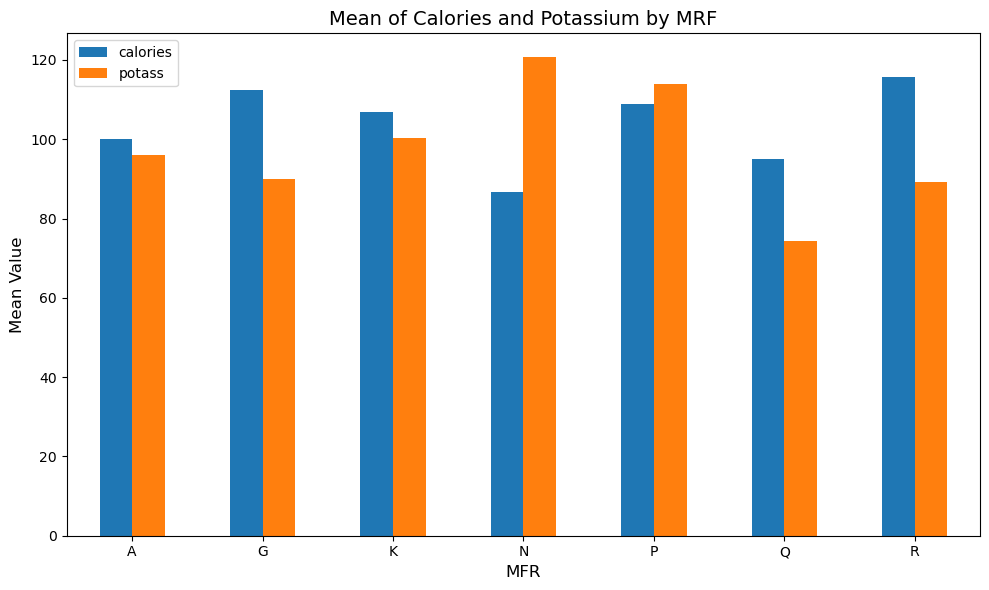

In [26]:
# The graph of the mean of ( 'calories' and 'potass’) by 'mfr ‘.
calories_mean = df.groupby('mfr')[['calories', 'potass']].mean()

# Plot the graph
calories_mean.plot(kind = 'bar', figsize=(10, 6))
plt.title('Mean of Calories and Potassium by MRF', fontsize=14)
plt.ylabel('Mean Value', fontsize=12)
plt.xlabel('MFR', fontsize=12)
plt.xticks(rotation = 0)
plt.tight_layout()

# Show the plot
plt.show()

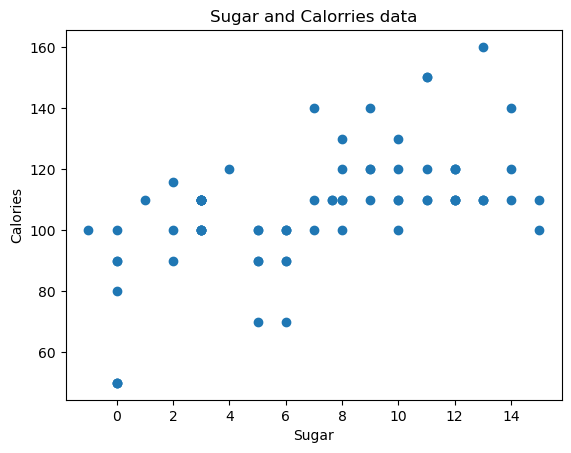

In [28]:
#Read 'sugars' & 'calories' data and show it using a scatter plot
plt.scatter(df['sugars'], df['calories'])
plt.xlabel('Sugar')
plt.ylabel('Calories')
plt.title('Sugar and Calorries data')
plt.show()

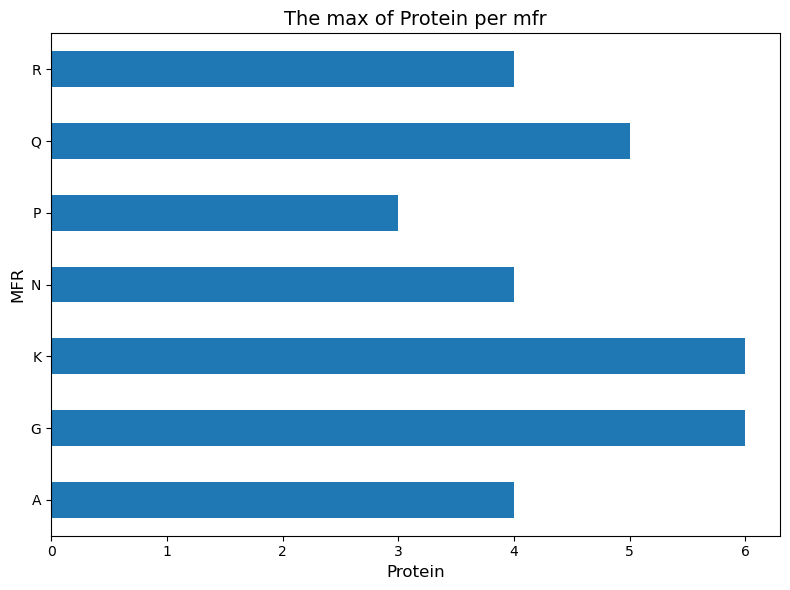

In [30]:
#In Horizontal bar chart display the max of 'Protein ' per 'mfr'.
max_protein_by_mfr = df.groupby('mfr')['protein'].max()
max_protein_by_mfr.plot(kind='barh', figsize=(8, 6))
                        
plt.title('The max of Protein per mfr', fontsize=14)
plt.ylabel('MFR', fontsize=12)
plt.xlabel('Protein', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

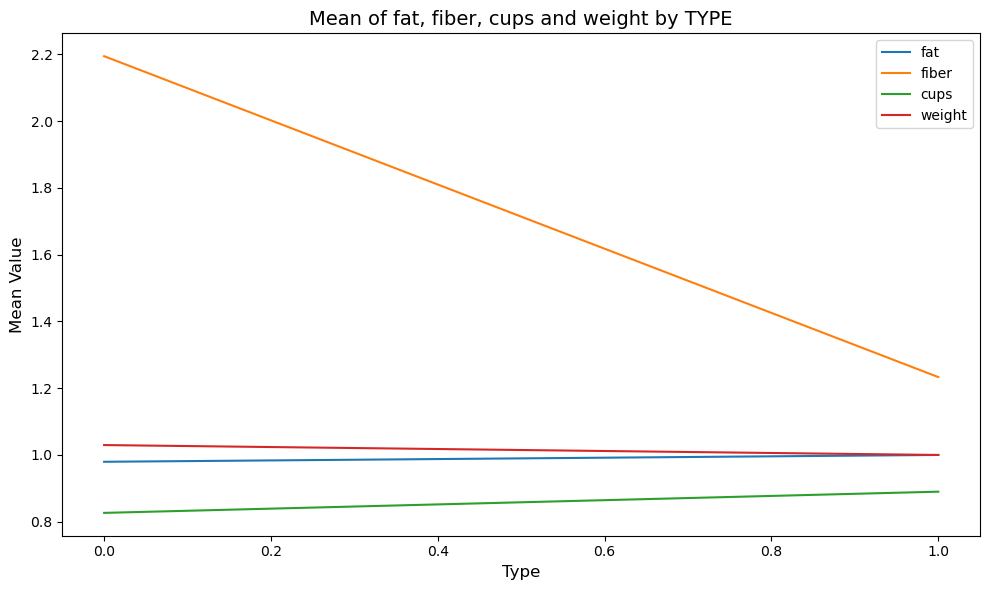

In [32]:
# The graph of the mean of ( 'fat', 'fiber', 'cups', 'weight') by 'type'.
mean_by_type = df.groupby('type')[['fat', 'fiber', 'cups', 'weight']].mean().reset_index()

mean_by_type.plot(kind='line', figsize=(10, 6))
plt.title('Mean of fat, fiber, cups and weight by TYPE', fontsize=14)
plt.ylabel('Mean Value', fontsize=12)
plt.xlabel('Type', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

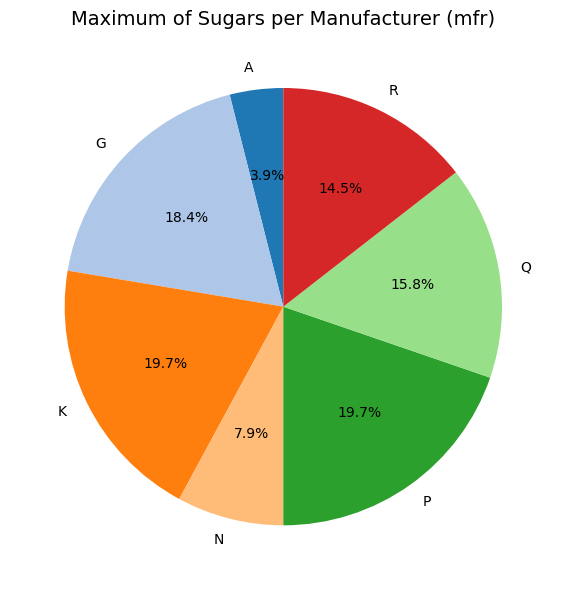

In [34]:
# Calculate the maximum of 'sugars' grouped by 'mfr'
max_sugar = df.groupby('mfr')['sugars'].max().reset_index()

# Create the pie chart
plt.figure(figsize=(10, 6))
plt.pie(
    max_sugar['sugars'], 
    labels=max_sugar['mfr'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=plt.cm.tab20.colors
)

# Add a title
plt.title('Maximum of Sugars per Manufacturer (mfr)', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()

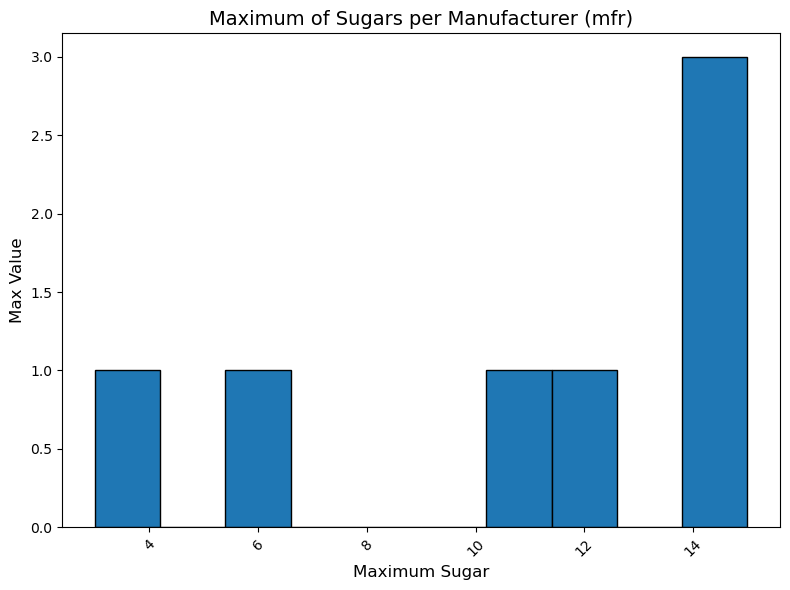

In [36]:
# Read the maximum of 'sugars ' of each ‘mfr and show it using the histogram to see most common ranges.
max_sugar = df.groupby('mfr')['sugars'].max()

max_sugar.plot(kind='hist', figsize=(8, 6),edgecolor='black')
plt.title('Maximum of Sugars per Manufacturer (mfr)', fontsize=14)
plt.ylabel('Max Value', fontsize=12)
plt.xlabel('Maximum Sugar', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

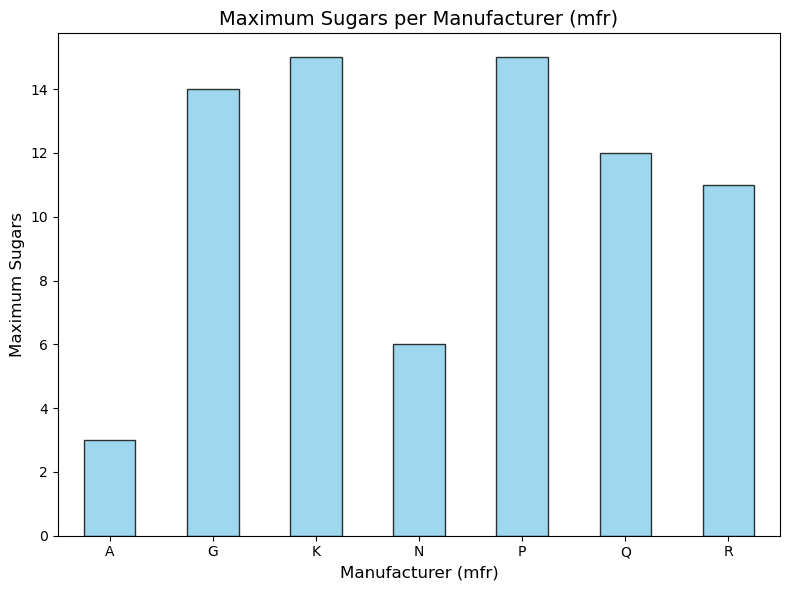

In [38]:
# Calculate the maximum of 'sugars' grouped by 'mfr'
max_sugar = df.groupby('mfr')['sugars'].max()

# Plot the bar chart
plt.figure(figsize=(8, 6))
max_sugar.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Maximum Sugars per Manufacturer (mfr)', fontsize=14)
plt.xlabel('Manufacturer (mfr)', fontsize=12)
plt.ylabel('Maximum Sugars', fontsize=12)
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.tight_layout()

# Show the plot
plt.show()

## Programming Algorithm challenges

In [41]:
df['Positive_Nutrition'] = df['calories'] + df['protein'] + df['vitamins']
df['Negative_Nutrition'] = 1+ df['sodium'] + df['sugars'] +df['fat']
df['The_Global_Nutrition'] = df['Positive_Nutrition'] / df['Negative_Nutrition']

In [43]:
# Assign Nutrition Categories using correct logical operators
df.loc[df['The_Global_Nutrition'] > 2, 'Nutrition_Category'] = 1
df.loc[(df['The_Global_Nutrition'] <= 2) & (df['The_Global_Nutrition'] > 0.5), 'Nutrition_Category'] = 2
df.loc[df['The_Global_Nutrition'] <= 0.5, 'Nutrition_Category'] = 3

In [45]:
df

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,Positive_Nutrition,Negative_Nutrition,The_Global_Nutrition,Nutrition_Category
0,Corn Chex,R,C,110.000000,2.0,0.0,280.0,0.0,22.0,3.0,25.0,25.0,1.0,1.0,1.00,41.445019,137.000000,284.0,0.482394,3.0
1,Corn Flakes,K,C,100.000000,2.0,0.0,290.0,1.0,21.0,2.0,35.0,25.0,1.0,1.0,1.00,45.863324,127.000000,293.0,0.433447,3.0
2,Rice Krispies,K,C,110.000000,2.0,0.0,290.0,0.0,22.0,3.0,35.0,25.0,1.0,1.0,1.00,40.560159,137.000000,294.0,0.465986,3.0
3,Special K,K,NaN,110.000000,6.0,0.0,230.0,1.0,16.0,3.0,55.0,25.0,1.0,1.0,1.00,53.131324,141.000000,234.0,0.602564,2.0
4,Multi-Grain Cheerios,G,C,100.000000,2.0,1.0,220.0,2.0,15.0,6.0,90.0,25.0,1.0,1.0,1.00,40.105965,127.000000,228.0,0.557018,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Grape Nuts Flakes,P,C,100.000000,3.0,1.0,140.0,3.0,15.0,5.0,85.0,25.0,3.0,1.0,0.88,52.076897,128.000000,147.0,0.870748,2.0
73,Rice Chex,R,C,115.714286,1.0,0.0,240.0,0.0,23.0,2.0,30.0,25.0,1.0,1.0,1.13,41.998933,141.714286,243.0,0.583186,2.0
74,Cheerios,G,C,110.000000,6.0,2.0,290.0,2.0,17.0,1.0,105.0,25.0,1.0,1.0,1.25,50.764999,141.000000,294.0,0.479592,3.0
75,Honey-comb,P,C,110.000000,1.0,0.0,180.0,0.0,14.0,11.0,35.0,25.0,1.0,1.0,1.33,28.742414,136.000000,192.0,0.708333,2.0


## Machine Learning

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [50]:
df2 = pd.read_excel("New_Cereal_List.xlsx")
df2

,Name,calories,protein,fat,fiber,carbo,sugars,potass,shelf
0,Azer_Food_X01,120,1,2,1,12,11,45,2
1,Azer_Food_X02,110,1,0,1,13,12,20,2
2,Azer_Food_X03,110,1,1,0,13,12,25,2
3,Azer_Food_X04,110,1,1,0,12,13,55,2
4,Azer_Food_X05,110,1,1,0,12,13,65,2
5,Azer_Food_X06,50,1,0,0,13,0,15,3
6,Azer_Food_X07,110,2,0,0,22,3,25,1
7,Azer_Food_X08,110,2,0,0,22,3,35,1
8,Azer_Food_X09,110,2,1,1,11,13,30,2
9,Azer_Food_X10,110,2,1,0,12,12,55,2


In [51]:
df2

,Name,calories,protein,fat,fiber,carbo,sugars,potass,shelf
0,Azer_Food_X01,120,1,2,1,12,11,45,2
1,Azer_Food_X02,110,1,0,1,13,12,20,2
2,Azer_Food_X03,110,1,1,0,13,12,25,2
3,Azer_Food_X04,110,1,1,0,12,13,55,2
4,Azer_Food_X05,110,1,1,0,12,13,65,2
5,Azer_Food_X06,50,1,0,0,13,0,15,3
6,Azer_Food_X07,110,2,0,0,22,3,25,1
7,Azer_Food_X08,110,2,0,0,22,3,35,1
8,Azer_Food_X09,110,2,1,1,11,13,30,2
9,Azer_Food_X10,110,2,1,0,12,12,55,2


In [52]:
# 資料預處理 - 處理缺失值並標準化特徵
df2 = df2.dropna()  # 刪除包含缺失值的行
features = ['calories', 'protein', 'fat', 'sugars', 'fiber']  # 假設的特徵欄位，根據資料集調整

# 特徵選擇與標準化
X = df2[features]  # 選擇對機器學習有用的欄位
scaler = StandardScaler()  # 用於標準化的處理
X_scaled = scaler.fit_transform(X)

# 使用 KMeans 聚類進行三類分類 (Cat1, Cat2, Cat3)
kmeans = KMeans(n_clusters=3, random_state=42)  # 假設有三個類別 (Cat1, Cat2, Cat3)
df2['Category'] = kmeans.fit_predict(X_scaled)  # 將預測的類別新增到資料集

# 將數字類別映射為 'Cat1', 'Cat2', 'Cat3'
category_mapping = {0: 'Cat1', 1: 'Cat2', 2: 'Cat3'}
df2['Category'] = df2['Category'].map(category_mapping)

# 顯示結果：根據營養類別整理的新穀物列表
print(df2[['Name', 'Category']])  # 假設 'name' 欄位包含穀物名稱

             Name Category
0   Azer_Food_X01     Cat3
1   Azer_Food_X02     Cat3
2   Azer_Food_X03     Cat3
3   Azer_Food_X04     Cat3
4   Azer_Food_X05     Cat3
5   Azer_Food_X06     Cat1
6   Azer_Food_X07     Cat1
7   Azer_Food_X08     Cat1
8   Azer_Food_X09     Cat3
9   Azer_Food_X10     Cat3
10  Azer_Food_X11     Cat1
11  Azer_Food_X12     Cat1
12  Azer_Food_X13     Cat1
13  Azer_Food_X14     Cat1
14  Azer_Food_X15     Cat1
15  Azer_Food_X16     Cat1
16  Azer_Food_X17     Cat1
17  Azer_Food_X18     Cat2
18  Azer_Food_X19     Cat2
19  Azer_Food_X20     Cat2


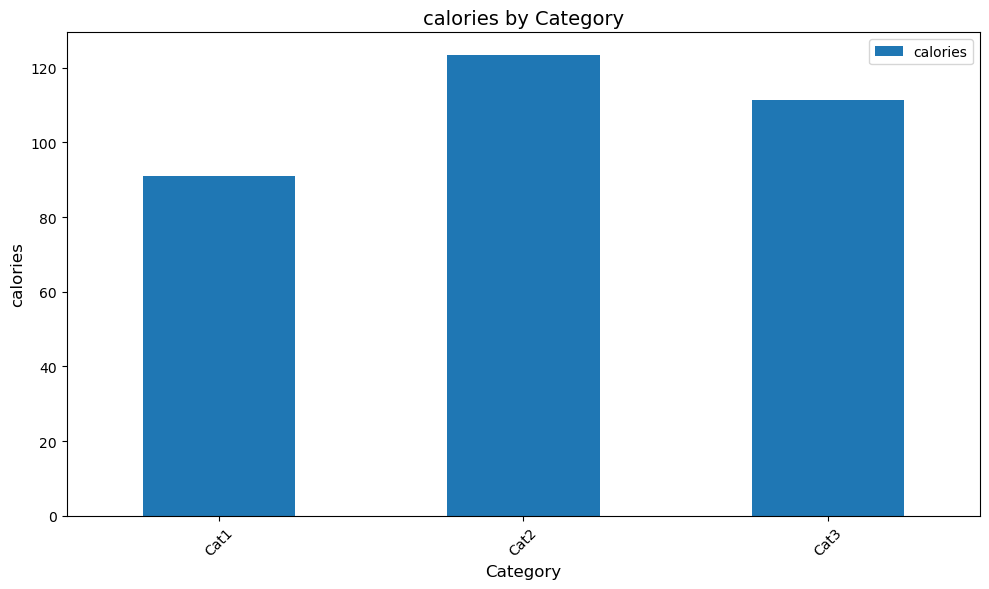

In [56]:
calories_by_Category = df2.groupby('Category')[['calories']].mean()

calories_by_Category.plot(kind='bar', figsize=(10, 6))
plt.title('calories by Category', fontsize=14)
plt.ylabel('calories', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()